## We Use FunctionTrasformer from sklearn.preprocessing

In [87]:
!pip install scipy

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score,accuracy_score

In [89]:
# Load the dataset with the necessary columns
dataset=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
dataset.sample(5)

,Survived,Age,Fare
762,1,20.0,7.2292
221,0,27.0,13.0000
849,1,NaN,89.1042
389,1,17.0,12.0000
286,1,30.0,9.5000


In [90]:
# Check & Fill the null values
imputer=SimpleImputer(strategy='mean')
# The Simputer will return us and 2d so we need to explictily convert it into dataframe
imputer.set_output(transform="pandas")
dataset=imputer.fit_transform(dataset)

In [91]:
dataset.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [92]:
dataset.sample()

,Survived,Age,Fare
712,1.0,48.0,52.0


In [93]:
# Train test Split the dataset

X_train,X_test,y_train,y_test=train_test_split(dataset.iloc[:,1:3],dataset.iloc[:,0],test_size=0.25,random_state=42)

In [94]:
X_train

,Age,Fare
298,29.699118,30.5000
884,25.000000,7.0500
247,24.000000,14.5000
478,22.000000,7.5208
305,0.920000,151.5500
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


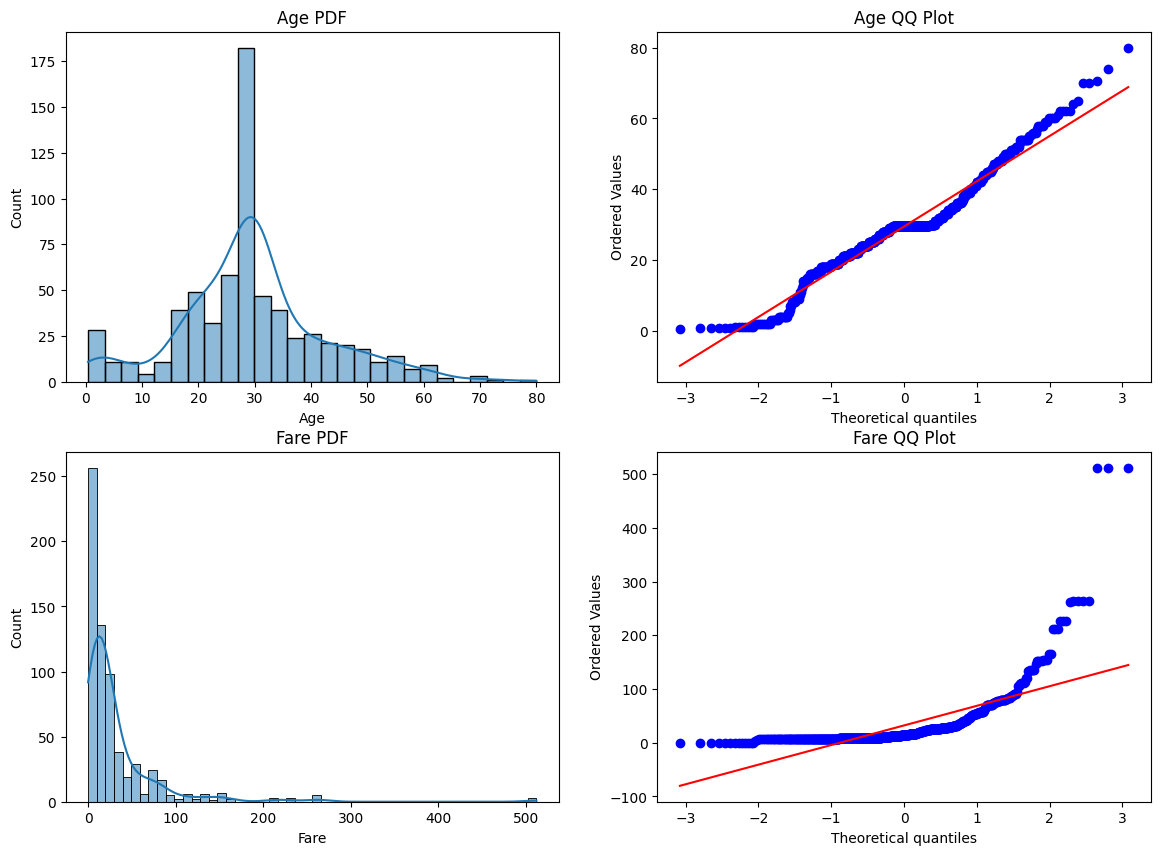

In [95]:
# plot dist plot and qq plot on the present data
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(222)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.subplot(223)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()


In [98]:
# By This we can see that Age is Near to Normal Distribution, where as fare is Right skewed Data
# Lets Train a Model With out any trasformation and check the accuracy. We will be using logistic regression for this classification problem.

pipe=Pipeline([
    ('model',LogisticRegression())
])

pipe.fit(X_train,y_train)
y_predicted=pipe.predict(X_test)
accuracy=accuracy_score(y_test,y_pred=y_predicted)
print('Accuracy Before trasformation:',accuracy)

Accuracy Before trasformation: 0.6636771300448431


In [99]:
# Now Lets apply FunctionTrasformation

transform=FunctionTransformer(func=np.log1p)
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

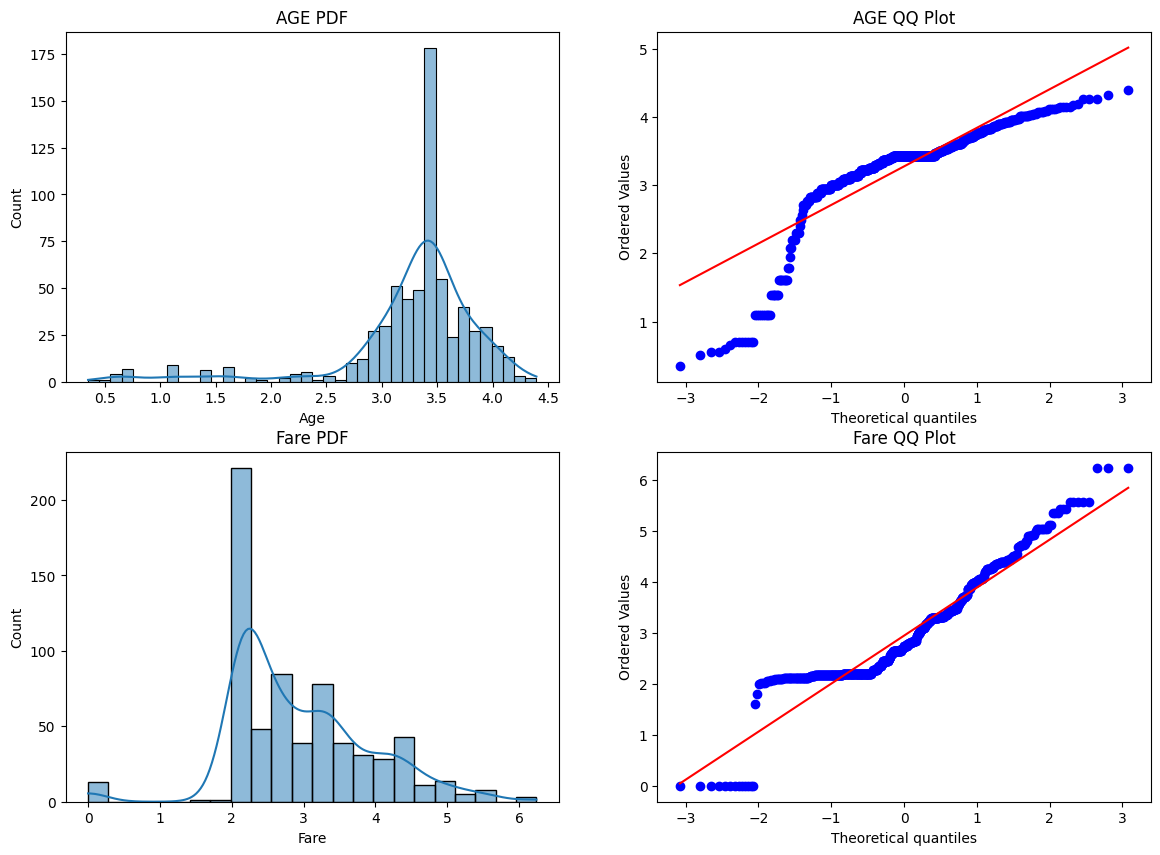

In [108]:
#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

In [116]:
# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


Accuracy after Trasfomation:  0.6816143497757847


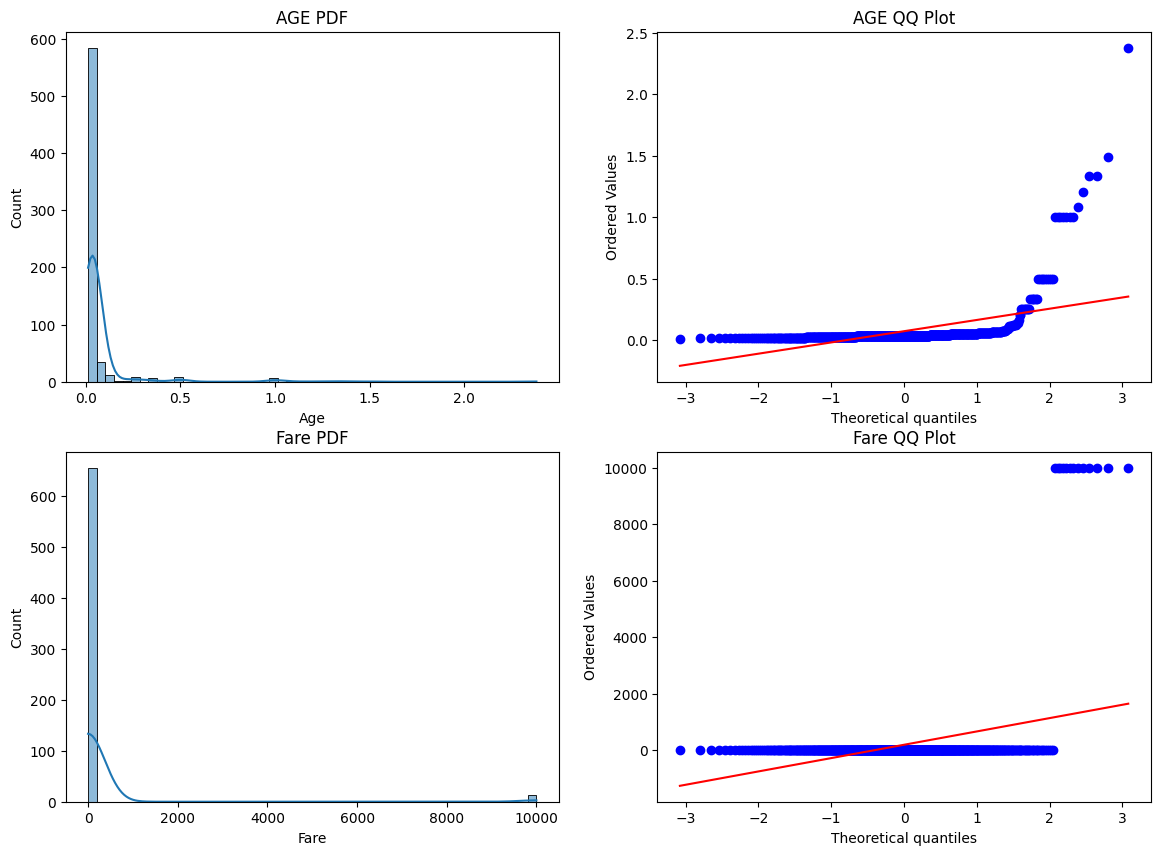

Accuracy after Trasfomation:  0.600896860986547


In [117]:
# Now Lets apply resiprocal

transform=FunctionTransformer(func=lambda x:1/(x+0.0001))
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


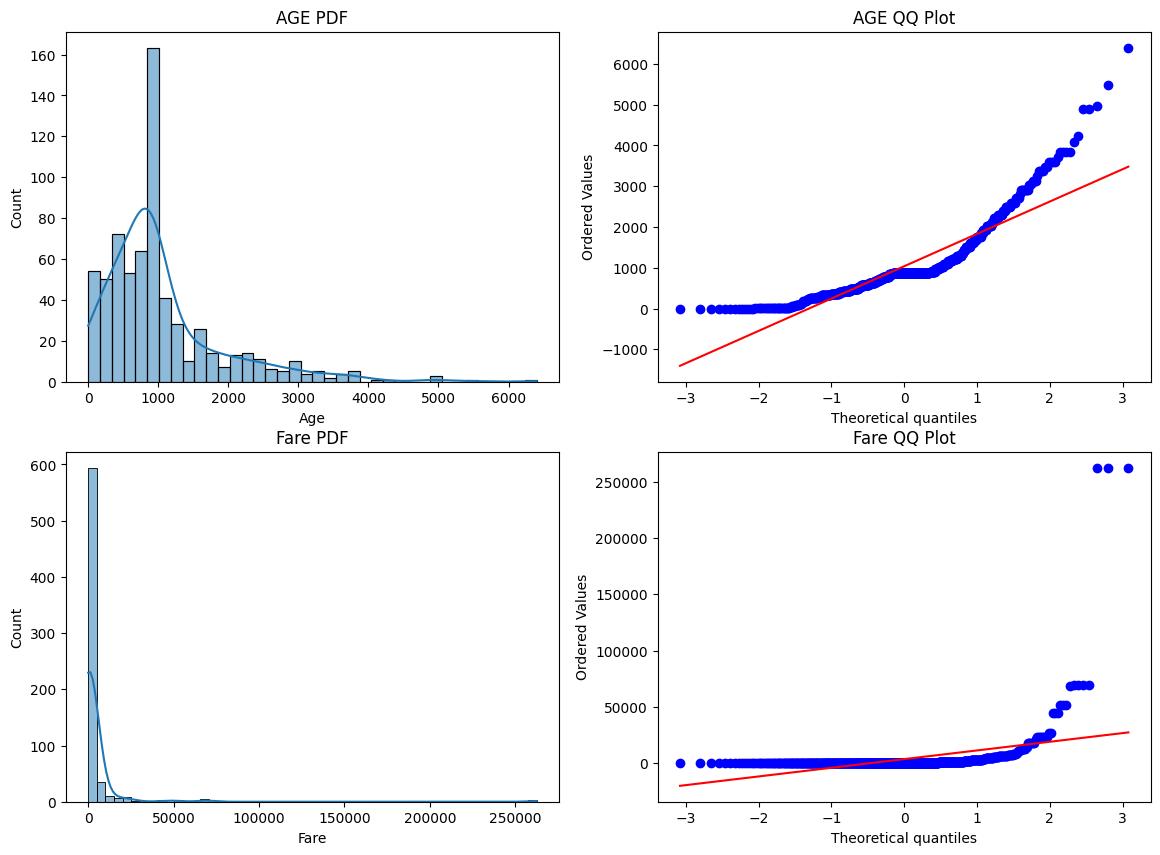

Accuracy after Trasfomation:  0.6278026905829597


In [118]:
# Lets apply x^2

transform=FunctionTransformer(func=lambda x:x**2)
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)


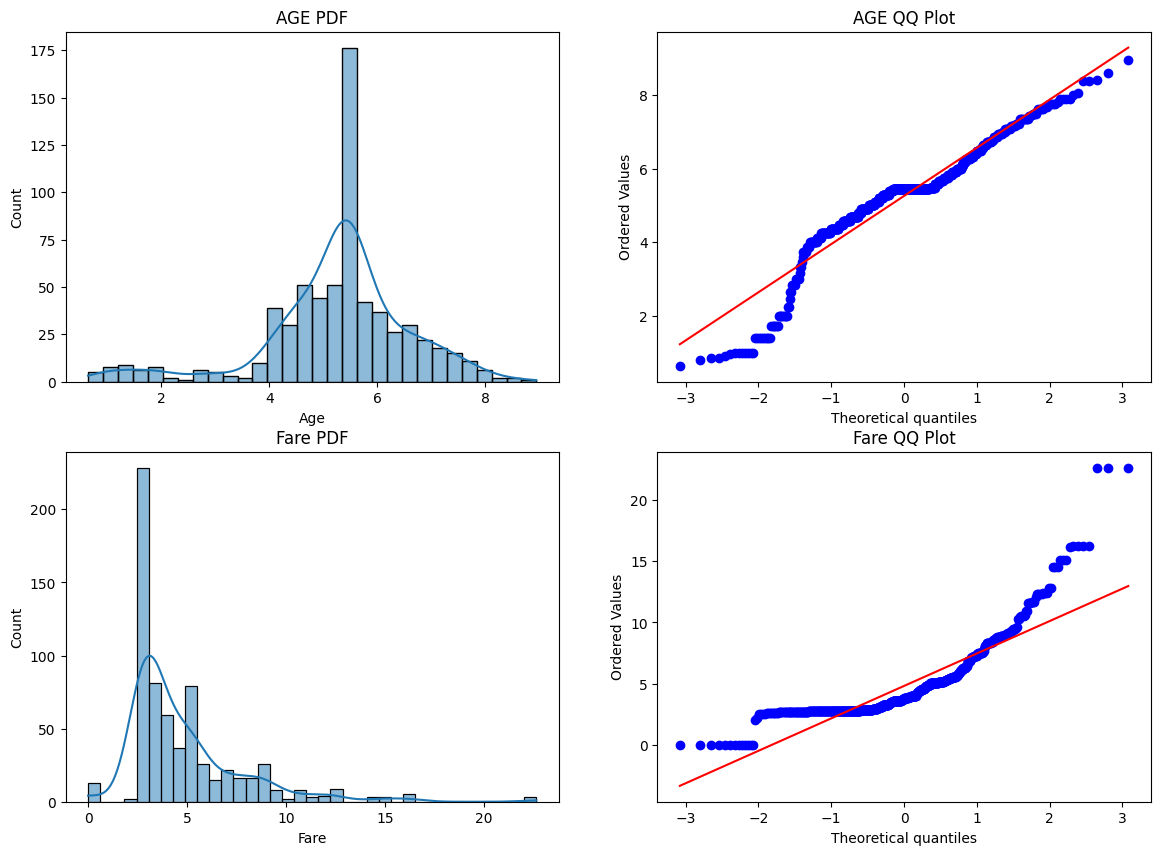

Accuracy after Trasfomation:  0.6816143497757847


In [119]:
# Lets apply sqrt(x)

transform=FunctionTransformer(func=lambda x:x**(1/2))
X_train_transform=transform.fit_transform(X_train)
X_test_transform=transform.transform(X_test)

#Plot the trasformed Dataset
plt.figure(figsize=(14,10))
plt.subplot(221)
sns.histplot(X_train_transform['Age'],kde=True)
plt.title('AGE PDF')

plt.subplot(222)
stats.probplot(X_train_transform['Age'],dist='norm',plot=plt)
plt.title('AGE QQ Plot')

plt.subplot(223)
sns.histplot(X_train_transform['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(224)
stats.probplot(X_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Train Model on the New Trasformation
pipe_trasform=Pipeline([
    ('model_trasform',LogisticRegression())
])
pipe_trasform.fit(X_train_transform,y_train)
y_predicted_trasformed=pipe_trasform.predict(X_test_transform)
accuracy_trasformed=accuracy_score(y_test,y_pred=y_predicted_trasformed)
print('Accuracy after Trasfomation: ',accuracy_trasformed)
